In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.signal import periodogram
import itertools
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Loading the dataset
df = pd.read_csv('medical_time_series_D213.csv')

In [3]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB


In [4]:
#Checking for duplicate values
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
726    False
727    False
728    False
729    False
730    False
Length: 731, dtype: bool


In [5]:
#Checking for missing values
print(df.isnull().sum())

Day        0
Revenue    0
dtype: int64


In [6]:
#Identify outliers based on Z-scores
z_scores = np.abs(zscore(df))
z_score_outliers = (z_scores > 3).sum(axis=0)
print("Outliers based on Z-score method:")
print(z_score_outliers)

Outliers based on Z-score method:
Day        0
Revenue    0
dtype: int64


In [7]:
#Sort values
df = df.sort_values("Day")

#Convert to integer
df["Day"] = df["Day"].astype(int)
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

In [8]:
#Confirm day coverage (gaps)
expected_days = np.arange(df["Day"].min(), df["Day"].max() + 1)
missing_days = sorted(list(set(expected_days) - set(df["Day"].values)))

In [9]:
#Daily DateTime index
df["Date"] = pd.to_datetime("2020-01-01") + pd.to_timedelta(df["Day"] - 1, unit="D")
df = df.set_index("Date").asfreq("D")
y = df["Revenue"]

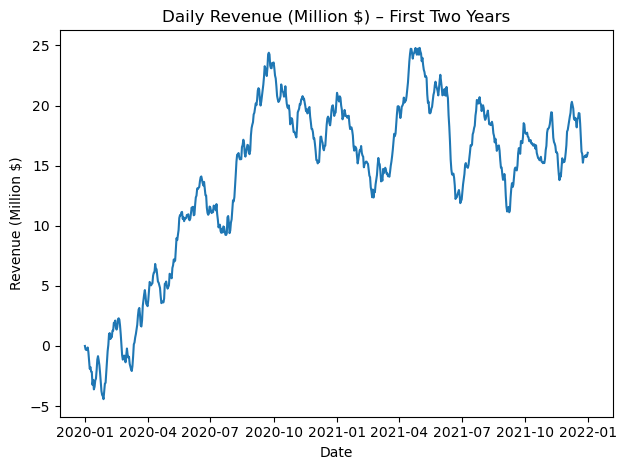

In [10]:
#Realization line graph
plt.figure()
plt.plot(y)
plt.title("Daily Revenue (Million $) – First Two Years")
plt.xlabel("Date")
plt.ylabel("Revenue (Million $)")
plt.tight_layout()
plt.show()

In [11]:
#Stationarity test (ADF)
adf_raw = adfuller(y, autolag="AIC")
print("\nADF test on raw series")
print("Test Statistic:", adf_raw[0])
print("p-value:", adf_raw[1])
print("Critical Values:", adf_raw[4])

y_diff1 = y.diff().dropna()
adf_diff1 = adfuller(y_diff1, autolag="AIC")
print("\nADF test on 1st-differenced series")
print("Test Statistic:", adf_diff1[0])
print("p-value:", adf_diff1[1])
print("Critical Values:", adf_diff1[4])


ADF test on raw series
Test Statistic: -2.2183190476089454
p-value: 0.19966400615064356
Critical Values: {'1%': -3.4393520240470554, '5%': -2.8655128165959236, '10%': -2.5688855736949163}

ADF test on 1st-differenced series
Test Statistic: -17.374772303557062
p-value: 5.113206978840171e-30
Critical Values: {'1%': -3.4393520240470554, '5%': -2.8655128165959236, '10%': -2.5688855736949163}


<Figure size 640x480 with 0 Axes>

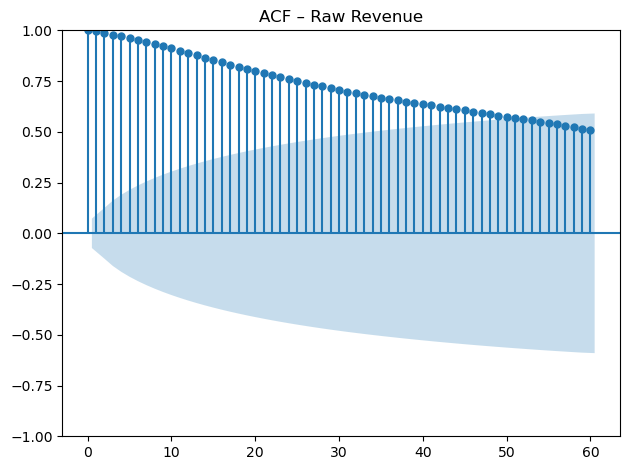

<Figure size 640x480 with 0 Axes>

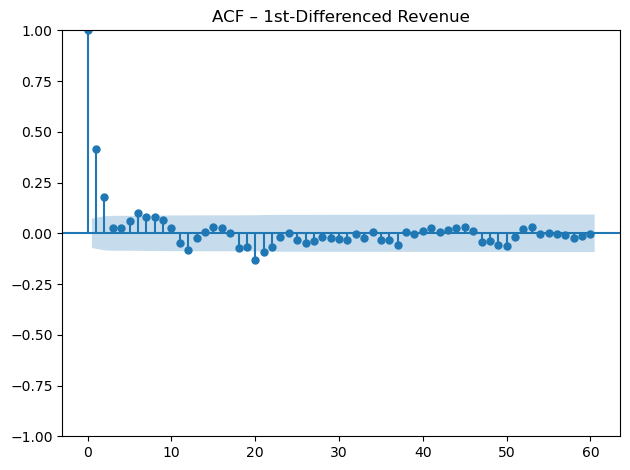

In [12]:
#ACF plots
plt.figure()
plot_acf(y, lags=60)
plt.title("ACF – Raw Revenue")
plt.tight_layout()
plt.show()

plt.figure()
plot_acf(y_diff1, lags=60)
plt.title("ACF – 1st-Differenced Revenue")
plt.tight_layout()
plt.show()

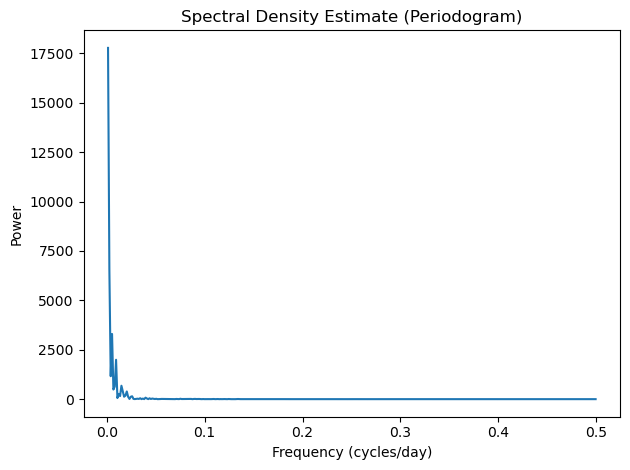

In [13]:
#Spectral density (periodogram)
freq, psd = periodogram(y.values, fs=1.0)  # 1 observation/day
plt.figure()
plt.plot(freq[1:], psd[1:])  # skip freq=0
plt.title("Spectral Density Estimate (Periodogram)")
plt.xlabel("Frequency (cycles/day)")
plt.ylabel("Power")
plt.tight_layout()
plt.show()

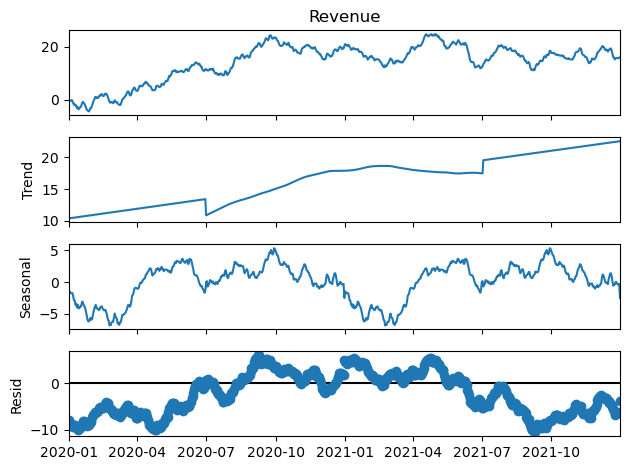

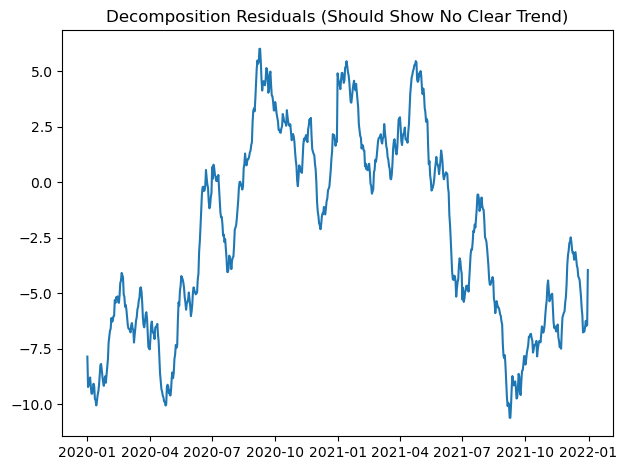

In [14]:
#Decomposition
decomp = seasonal_decompose(y, model="additive", period=365, extrapolate_trend="freq")
decomp.plot()
plt.tight_layout()
plt.show()

# Residuals trend check (visual)
plt.figure()
plt.plot(decomp.resid)
plt.title("Decomposition Residuals (Should Show No Clear Trend)")
plt.tight_layout()
plt.show()

In [15]:
#Train-test split
test_size = 90  # 90-day forecast horizon
train = y.iloc[:-test_size]
test  = y.iloc[-test_size:]

print("\nTrain length:", len(train))
print("Test length:", len(test))


Train length: 641
Test length: 90


In [16]:
#Model identification via small grid search (AIC)
pdq = list(itertools.product(range(0, 4), [1], range(0, 4)))  # try 0..3 for p and q
fixed_seasonal = (0, 1, 0, 365)

results = []
failures = 0

for order in pdq:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=fixed_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=True  # helps when data is short vs seasonal period
        )
        res = model.fit(disp=False, method="lbfgs", maxiter=200)

        results.append((order, fixed_seasonal, res.aic))
        print(f"OK   SARIMA{order}x{fixed_seasonal}  AIC={res.aic:.2f}")

    except Exception as e:
        failures += 1
        print(f"FAIL SARIMA{order}x{fixed_seasonal}  -> {type(e).__name__}: {e}")

print("\nSuccessful models:", len(results))
print("Failed models:", failures)

if len(results) == 0:
    raise RuntimeError(
        "No models fit successfully. Next step: switch seasonality to 7 (weekly) or remove seasonality."
    )

results_df = pd.DataFrame(results, columns=["order", "seasonal_order", "AIC"]).sort_values("AIC").reset_index(drop=True)

print("\nTop 10 by AIC:")
print(results_df.head(10))

best_order = tuple(results_df.loc[0, "order"])
best_seasonal = tuple(results_df.loc[0, "seasonal_order"])
best_aic = float(results_df.loc[0, "AIC"])

print("\nBEST MODEL (lowest AIC)")
print("order:", best_order)
print("seasonal_order:", best_seasonal)
print("AIC:", round(best_aic, 2))


OK   SARIMA(0, 1, 0)x(0, 1, 0, 365)  AIC=602.88
OK   SARIMA(0, 1, 1)x(0, 1, 0, 365)  AIC=555.13
OK   SARIMA(0, 1, 2)x(0, 1, 0, 365)  AIC=537.44
OK   SARIMA(0, 1, 3)x(0, 1, 0, 365)  AIC=537.10
OK   SARIMA(1, 1, 0)x(0, 1, 0, 365)  AIC=543.69
OK   SARIMA(1, 1, 1)x(0, 1, 0, 365)  AIC=543.55
OK   SARIMA(1, 1, 2)x(0, 1, 0, 365)  AIC=539.43
OK   SARIMA(1, 1, 3)x(0, 1, 0, 365)  AIC=539.85
OK   SARIMA(2, 1, 0)x(0, 1, 0, 365)  AIC=543.55
OK   SARIMA(2, 1, 1)x(0, 1, 0, 365)  AIC=545.51
OK   SARIMA(2, 1, 2)x(0, 1, 0, 365)  AIC=541.23
OK   SARIMA(2, 1, 3)x(0, 1, 0, 365)  AIC=540.84
OK   SARIMA(3, 1, 0)x(0, 1, 0, 365)  AIC=541.57
OK   SARIMA(3, 1, 1)x(0, 1, 0, 365)  AIC=540.80
OK   SARIMA(3, 1, 2)x(0, 1, 0, 365)  AIC=542.79
OK   SARIMA(3, 1, 3)x(0, 1, 0, 365)  AIC=538.96

Successful models: 16
Failed models: 0

Top 10 by AIC:
       order  seasonal_order         AIC
0  (0, 1, 3)  (0, 1, 0, 365)  537.096483
1  (0, 1, 2)  (0, 1, 0, 365)  537.442282
2  (3, 1, 3)  (0, 1, 0, 365)  538.957278
3  (1, 1, 2)

In [17]:
#Fit final model
best_order = (0, 1, 3)
best_seasonal = (0, 1, 0, 365)

final_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, method="lbfgs", maxiter=500)

print(final_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              Revenue   No. Observations:                  641
Model:             SARIMAX(0, 1, 3)x(0, 1, [], 365)   Log Likelihood                -264.744
Date:                              Mon, 11 May 2026   AIC                            537.487
Time:                                      06:28:41   BIC                            551.896
Sample:                                  01-01-2020   HQIC                           543.272
                                       - 10-02-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4634      0.065      7.153      0.000       0.336       0.590
ma.L2          0.25

In [18]:
#Forecast (test horizon)
forecast_res = final_model.get_forecast(steps=len(test))
pred_mean = forecast_res.predicted_mean
pred_ci = forecast_res.conf_int(alpha=0.05)

In [19]:
#Forecast table
forecast_table = pd.DataFrame({
    "Actual_Revenue": test,
    "Forecast_Mean": pred_mean,
    "Lower_95_PI": pred_ci.iloc[:, 0],
    "Upper_95_PI": pred_ci.iloc[:, 1]
})

print("\nForecast Table Head (First 10 Rows):")
print(forecast_table.head(10))

print("\nForecast Table Tail(Last 10 Rows):")
print(forecast_table.tail(10))


Forecast Table Head (First 10 Rows):
            Actual_Revenue  Forecast_Mean  Lower_95_PI  Upper_95_PI
2021-10-03       17.654350      17.272313    16.012592    18.532035
2021-10-04       17.743343      17.252786    15.020053    19.485519
2021-10-05       17.415157      16.578642    13.465683    19.691600
2021-10-06       17.358496      15.784572    12.003025    19.566120
2021-10-07       17.033950      15.487297    11.138769    19.835824
2021-10-08       17.023974      15.277595    10.427927    20.127263
2021-10-09       17.129247      15.363986    10.060320    20.667652
2021-10-10       16.852155      15.506898     9.785145    21.228652
2021-10-11       16.876321      15.756750     9.645445    21.868055
2021-10-12       16.741968      16.735309    10.257837    23.212781

Forecast Table Tail(Last 10 Rows):
            Actual_Revenue  Forecast_Mean  Lower_95_PI  Upper_95_PI
2021-12-22       16.155111      13.333505    -5.882076    32.549085
2021-12-23       15.981459      13.815122 

In [20]:
#Evaluation
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
print("\nTest MAE:", round(mae, 4))
print("Test RMSE:", round(rmse, 4))


Test MAE: 3.0017
Test RMSE: 3.9846


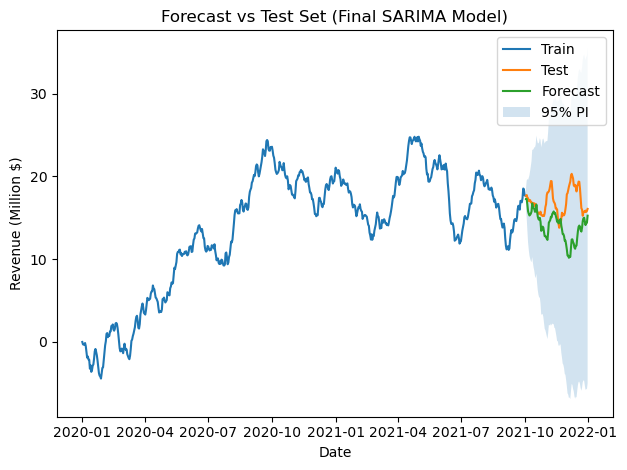

In [21]:
#Plot forecast vs test set (annotated visualization)
plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(pred_mean.index, pred_mean, label="Forecast")
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], alpha=0.2, label="95% PI")
plt.title("Forecast vs Test Set (Final SARIMA Model)")
plt.xlabel("Date")
plt.ylabel("Revenue (Million $)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
#Save cleaned dataset
new_data_path = 'output/cleaned_medical_time_series.csv'
df.to_csv(new_data_path, index=False)